Loading top_5000_yf_data.pkl...
Data loaded successfully.
Universe shape: (4117, 5002)


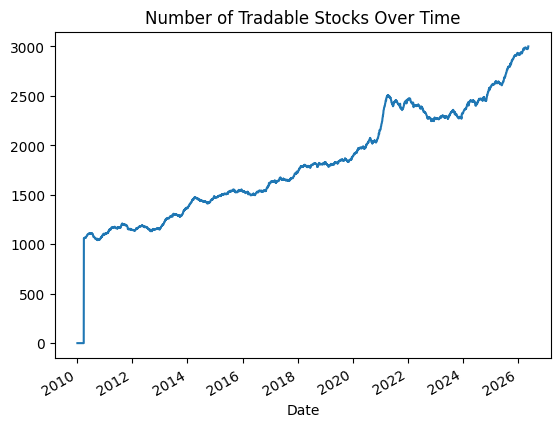

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from QRT_comp.phase2_qrt_challenge.scripts.utils import backtest_portfolio
import pandas as pd

# Load the downloaded Yahoo Finance data
print('Loading top_5000_yf_data.pkl...')
df_historical = pd.read_pickle('../top_5000_yf_data.pkl')
print('Data loaded successfully.')

# 1. Calculate Average Daily Volume (ADV) for trailing 60 days\n,
df_daily_volume = df_historical['Close'].mul(df_historical['Volume']).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=60).mean()

# Creating Universe based on all constraints
df_universe_5m = ((df_adv_60 >= 5_000_000)).astype(int)
print('Universe shape:', df_universe_5m.shape)

df_universe_5m.sum(axis=1).plot(title="Number of Tradable Stocks Over Time")

# Saving 5M universe to stores folder
# Drop any duplicated columns
df_universe_5m = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]

# Calculating returns for each ticker every day
# Using Adj Close to account for dividends and stock splits
returns = df_historical['Adj Close'].pct_change(fill_method=None).fillna(0)

# Saving returns to parquet file
# Drop any duplicated columns
returns = returns.loc[:, ~returns.columns.duplicated()]

In [4]:
import pandas as pd
import numpy as np

def generate_yearly_tearsheet(portfolio, returns):
    print("Generating Yearly Tear Sheet...")
    
    # 1. Recalculate Daily PnL and Costs (matching your backtest logic)
    portfolio = portfolio.fillna(0)
    rets = returns.fillna(0)
    
    gross_pnl = (portfolio * rets).sum(axis=1)
    traded = portfolio.diff(1).abs().sum(axis=1).fillna(0)
    book_value = portfolio.abs().sum(axis=1)
    
    execution_cost = traded * 2e-4
    financing_cost = book_value * (0.005 / 252)
    net_pnl = gross_pnl - execution_cost - financing_cost
    
    # Create a DataFrame to hold daily portfolio data
    df_perf = pd.DataFrame({
        'Gross_PnL': gross_pnl,
        'Net_PnL': net_pnl,
        'Traded': traded,
        'Book_Value': book_value
    })
    
    # Add Year column for grouping
    df_perf['Year'] = df_perf.index.year
    
    # 2. Define metric calculations per year
    yearly_metrics = []
    
    for year, group in df_perf.groupby('Year'):
        # Skip years with less than 50 trading days (e.g., partial first year)
        if len(group) < 50:
            continue
            
        # Returns
        gross_ret = group['Gross_PnL'].sum()
        net_ret = group['Net_PnL'].sum()
        
        # Volatility & Sharpe (Annualized)
        daily_vol = group['Net_PnL'].std()
        ann_vol = daily_vol * np.sqrt(252)
        net_sharpe = (group['Net_PnL'].mean() / daily_vol) * np.sqrt(252) if daily_vol > 0 else 0
        
        # Hit Rate (Percentage of days with strictly positive Net PnL)
        win_days = (group['Net_PnL'] > 0).sum()
        total_days = len(group)
        hit_rate = win_days / total_days
        
        # Max Drawdown
        cum_net = group['Net_PnL'].cumsum()
        running_max = cum_net.cummax()
        drawdown = cum_net - running_max
        max_dd = drawdown.min()
        
        # Annualized Turnover (Daily mean traded / mean book * 252)
        mean_traded = group['Traded'].mean()
        mean_book = group['Book_Value'].mean()
        ann_turnover = (mean_traded / mean_book) * 252 if mean_book > 0 else 0
        
        yearly_metrics.append({
            'Year': year,
            'Net Return (%)': round(net_ret * 100, 2),
            'Gross Return (%)': round(gross_ret * 100, 2),
            'Net Sharpe': round(net_sharpe, 2),
            'Max Drawdown (%)': round(max_dd * 100, 2),
            'Daily Win Rate (%)': round(hit_rate * 100, 2),
            'Ann. Turnover (%)': round(ann_turnover * 100, 2)
        })
    
    # 3. Format and output
    df_tearsheet = pd.DataFrame(yearly_metrics).set_index('Year')
    
    # Calculate Overall Stats to append at the bottom
    overall_net_ret = df_perf['Net_PnL'].sum()
    overall_gross_ret = df_perf['Gross_PnL'].sum()
    overall_vol = df_perf['Net_PnL'].std() * np.sqrt(252)
    overall_sharpe = (df_perf['Net_PnL'].mean() / df_perf['Net_PnL'].std()) * np.sqrt(252)
    
    cum_net_all = df_perf['Net_PnL'].cumsum()
    max_dd_all = (cum_net_all - cum_net_all.cummax()).min()
    overall_win = (df_perf['Net_PnL'] > 0).sum() / len(df_perf)
    overall_turnover = (df_perf['Traded'].mean() / df_perf['Book_Value'].mean()) * 252
    
    print("\n--- YEARLY PERFORMANCE TEAR SHEET ---")
    display(df_tearsheet)
    
    print("\n--- OVERALL METRICS ---")
    print(f"Total Net Return:   {round(overall_net_ret * 100, 2)}%")
    print(f"Total Gross Return: {round(overall_gross_ret * 100, 2)}%")
    print(f"Overall Net Sharpe: {round(overall_sharpe, 2)}")
    print(f"Max Drawdown:       {round(max_dd_all * 100, 2)}%")
    print(f"Daily Win Rate:     {round(overall_win * 100, 2)}%")
    print(f"Ann. Turnover:      {round(overall_turnover * 100, 2)}%")
    
    return df_tearsheet


In [11]:
import yfinance as yf
import numpy as np
import pandas as pd

# ==========================================
# PRE-REQUISITES: Ensure `returns`, `df_historical` (OHLC), and `df_universe_5m` are loaded.
# ==========================================

print("=== STARTING TREND-ALIGNED BOLLINGER PIPELINE ===")

# ==========================================
# PHASE 1: SPY Hedging & Residual Returns
# ==========================================
print("Phase 1: Calculating Beta and Residual Returns...")
start_date = returns.index.min()
end_date = returns.index.max() + pd.Timedelta(days=1)
spy_df = yf.download('SPY', start=start_date, end=end_date, progress=False)

if isinstance(spy_df.columns, pd.MultiIndex):
    spy_df.columns = spy_df.columns.droplevel(1)
spy_adj_close = spy_df['Adj Close'].squeeze() if 'Adj Close' in spy_df.columns else spy_df['Close'].squeeze()
if spy_adj_close.index.tz is not None:
    spy_adj_close.index = spy_adj_close.index.tz_localize(None)

spy_rets_aligned = np.log(spy_adj_close / spy_adj_close.shift(1)).reindex(returns.index).fillna(0)

ROLLING_WINDOW = 252
spy_var = spy_rets_aligned.rolling(window=ROLLING_WINDOW, min_periods=63).var()
rolling_cov = returns.rolling(window=ROLLING_WINDOW, min_periods=63).cov(spy_rets_aligned)
rolling_beta = rolling_cov.div(spy_var, axis=0).fillna(1.0)
residual_returns = returns - rolling_beta.multiply(spy_rets_aligned, axis=0)


# ==========================================
# PHASE 2: Trend-Aligned Bollinger Z-Scores (CORRECTED)
# ==========================================
print("Phase 2: Generating Absolute Trend-Aligned Signals...")

# Synthesize residual price paths
residual_prices = (1 + residual_returns).cumprod()

# 1. The Trend Filter (100-Day SMA)
sma_100 = residual_prices.rolling(window=100).mean()
trend_up = residual_prices > sma_100
trend_down = residual_prices < sma_100

# 2. The Mean Reversion Trigger (20-Day Bollinger Z-Scores)
sma_20 = residual_prices.rolling(window=20).mean()
std_20 = residual_prices.rolling(window=20).std()

# Z-Score = standard deviations away from the 20-day mean
bollinger_z = (residual_prices - sma_20) / std_20
valid_bollinger_z = bollinger_z * df_universe_5m.replace(0, np.nan)

# --- THE FIX: Absolute Thresholds, NO RANKING ---
# A Z-score of -2.0 is the classic Lower Bollinger Band
# A Z-score of +2.0 is the classic Upper Bollinger Band
LONG_ENTER = -2.5  # Hyper-sparse: only buy extreme -2.5 Std Dev crashes
LONG_EXIT = 0.0    # Exit at the 20-day mean (Z = 0)

SHORT_ENTER = 2.5  # Hyper-sparse: only short extreme +2.5 Std Dev rips
SHORT_EXIT = 0.0   # Cover at the 20-day mean (Z = 0)

print("Applying Absolute Hysteresis Logic...")

# LONGS: Absolute Oversold (Z < -2.5) AND in a Long-Term Uptrend
long_state = pd.DataFrame(index=valid_bollinger_z.index, columns=valid_bollinger_z.columns, data=np.nan)
long_state[(valid_bollinger_z <= LONG_ENTER) & trend_up] = 1   
long_state[(valid_bollinger_z >= LONG_EXIT) | trend_down] = -1 # Eject on mean reversion or trend break
long_signals = long_state.ffill().replace(-1, 0).fillna(0)

# SHORTS: Absolute Overbought (Z > 2.5) AND in a Long-Term Downtrend
short_state = pd.DataFrame(index=valid_bollinger_z.index, columns=valid_bollinger_z.columns, data=np.nan)
short_state[(valid_bollinger_z >= SHORT_ENTER) & trend_down] = 1 
short_state[(valid_bollinger_z <= SHORT_EXIT) | trend_up] = -1 # Eject on mean reversion or trend break
short_signals = short_state.ffill().replace(-1, 0).fillna(0) * -1

df_tradable_signal = (long_signals + short_signals).fillna(0)
print("Corrected Bollinger Signals generated.")

# ==========================================
# PHASE 4: Institutional Portfolio Construction (2-Day Frequency)
# ==========================================
print("Phase 4: Constructing Sector-Neutral Portfolio...")
TARGET_VOL = 0.40 
raw_weights = df_tradable_signal * (TARGET_VOL / df_vol_floored) * df_universe_5m

# --- THE FIX: 2-Business-Day Resampling ---
# This updates target weights every 2nd trading day (e.g., Mon, Wed, Fri, Tue, Thu...)
sampled_raw_weights = raw_weights.resample('2B').last()
# ------------------------------------------

long_w = sampled_raw_weights.where(sampled_raw_weights > 0, 0)
short_w = sampled_raw_weights.where(sampled_raw_weights < 0, 0).abs()

def enforce_strict_constraints(weight_matrix, target_sum=0.50, max_weight=0.099, max_iterations=7):
    w = weight_matrix.copy()
    for _ in range(max_iterations):
        current_sum = w.sum(axis=1) + 1e-10
        w = w.div(current_sum, axis=0) * target_sum
        w = w.clip(upper=max_weight)
    valid_rows = w.sum(axis=1) >= (target_sum - 0.005)
    w = w.multiply(valid_rows, axis=0)
    return w

normalized_longs = enforce_strict_constraints(long_w)
normalized_shorts = enforce_strict_constraints(short_w)
portfolio_sampled = normalized_longs - normalized_shorts

# Shift (T+1) to ensure no look-ahead bias, then expand back to daily for the backtester
portfolio_shifted = portfolio_sampled.reindex(returns.index).ffill().shift(1)

# Clean up shapes and duplicates
portfolio_shifted = portfolio_shifted.loc[:, ~portfolio_shifted.columns.duplicated()]
safe_returns = returns.loc[:, ~returns.columns.duplicated()]
safe_universe = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]

portfolio_aligned = portfolio_shifted.reindex(columns=safe_returns.columns, fill_value=0)
portfolio_masked = portfolio_aligned * safe_universe

final_longs = portfolio_masked.where(portfolio_masked > 0, 0)
final_shorts = portfolio_masked.where(portfolio_masked < 0, 0).abs()
portfolio_final = (enforce_strict_constraints(final_longs) - enforce_strict_constraints(final_shorts)).fillna(0)
print("2-Day Portfolio ready.")


# ==========================================
# PHASE 5: Broad Regime Filter & Execution
# ==========================================
print("Phase 5: Applying Macro Filters and Executing...")
spy_prices = spy_adj_close.reindex(returns.index).ffill()
spy_sma_200 = spy_prices.rolling(window=200).mean()
trend_is_positive = spy_prices > spy_sma_200

spy_daily_rets = np.log(spy_prices / spy_prices.shift(1))
spy_ann_vol = spy_daily_rets.rolling(window=20).std() * np.sqrt(252)
volatility_is_safe = spy_ann_vol < 0.35

regime_mask = (trend_is_positive & volatility_is_safe).shift(1).fillna(False)
portfolio_regime_filtered = portfolio_final.multiply(regime_mask, axis=0)

print(f"Regime Filter Active. Trading halted on {(~regime_mask).sum()} out of {len(regime_mask)} days.")

net_sharpe, pnl_series = backtest_portfolio(
    portfolio=portfolio_regime_filtered.shift(1), 
    returns=safe_returns, 
    universe=safe_universe.shift(1), 
    plot_=True, 
    print_=True
)

tearsheet_df = generate_yearly_tearsheet(portfolio_regime_filtered, safe_returns)
print("=== PIPELINE COMPLETE ===")

=== STARTING TREND-ALIGNED BOLLINGER PIPELINE ===
Phase 1: Calculating Beta and Residual Returns...
Phase 2: Generating Absolute Trend-Aligned Signals...
Applying Absolute Hysteresis Logic...
Corrected Bollinger Signals generated.
Phase 4: Constructing Sector-Neutral Portfolio...
2-Day Portfolio ready.
Phase 5: Applying Macro Filters and Executing...
Regime Filter Active. Trading halted on 803 out of 4117 days.


C:\Users\USER\AppData\Local\Temp\ipykernel_17672\1131200750.py:139: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  regime_mask = (trend_is_positive & volatility_is_safe).shift(1).fillna(False)


Gross Sharpe Ratio:  0.492
Net Sharpe Ratio:  0.249
Turnover %:  36.035


Generating Yearly Tear Sheet...

--- YEARLY PERFORMANCE TEAR SHEET ---


,Net Return (%),Gross Return (%),Net Sharpe,Max Drawdown (%),Daily Win Rate (%),Ann. Turnover (%)
Year,,,,,,
2010,-8.85,-8.39,-2.71,-9.47,5.95,8513.21
2011,-20.45,-18.85,-3.08,-23.62,28.97,10576.36
2012,-57.59,-55.48,-7.98,-58.85,30.40,8437.51
2013,-38.29,-36.22,-5.93,-38.23,38.49,8452.80
2014,-45.04,-42.91,-6.50,-46.90,34.13,8743.82
2015,-35.32,-33.46,-4.61,-35.94,29.37,9552.96
2016,-38.15,-36.43,-4.73,-39.86,29.76,8528.44
2017,-50.05,-47.88,-6.25,-50.37,37.45,8401.86
2018,-34.95,-33.01,-4.60,-34.94,34.26,9190.52



--- OVERALL METRICS ---
Total Net Return:   -732.4%
Total Gross Return: -702.66%
Overall Net Sharpe: -4.95
Max Drawdown:       -733.02%
Daily Win Rate:     29.63%
Ann. Turnover:      9082.57%
=== PIPELINE COMPLETE ===
